<a href="https://colab.research.google.com/github/batgirlsupimpa/UFSC/blob/main/TRABALHO_ECONOMETRIA_GVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Growth.xlsx to Growth.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


    country_name    growth  oil       rgdp60  tradeshare  yearsschool  \
0          India  1.915168    0   765.999817    0.140502         1.45   
1      Argentina  0.617645    0  4462.001465    0.156623         4.99   
2          Japan  4.304759    0  2953.999512    0.157703         6.71   
3         Brazil  2.930097    0  1783.999878    0.160405         2.89   
4  United States  1.712265    0  9895.003906    0.160815         8.66   

   rev_coups  assasinations  
0   0.133333       0.866667  
1   0.933333       1.933333  
2   0.000000       0.200000  
3   0.100000       0.100000  
4   0.000000       0.433333  
Index(['country_name', 'growth', 'oil', 'rgdp60', 'tradeshare', 'yearsschool',
       'rev_coups', 'assasinations'],
      dtype='object')


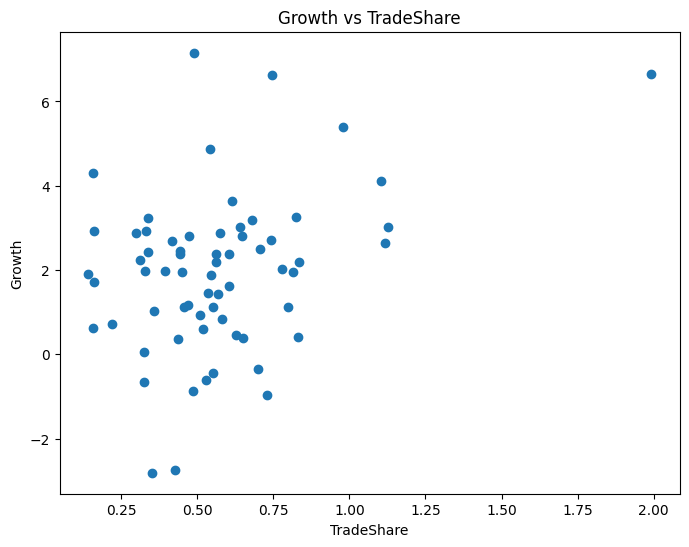


Correlação:
0.35168197240405297

Dados de Malta:
   country_name    growth  oil  rgdp60  tradeshare  yearsschool  rev_coups  \
64        Malta  6.652838    0  1374.0    1.992616         5.64        0.0   

    assasinations  
64            0.0  


/tmp/ipykernel_6666/350381425.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(malta["tradeshare"]),
/tmp/ipykernel_6666/350381425.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(malta["growth"])


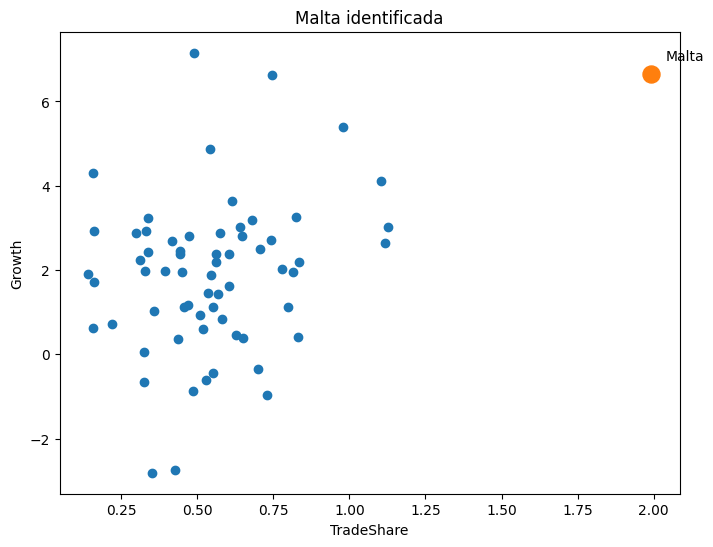


REGRESSÃO COM MALTA
                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     8.892
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00407
Time:                        22:46:45   Log-Likelihood:                -129.06
No. Observations:                  65   AIC:                             262.1
Df Residuals:                      63   BIC:                             266.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6403      0.49

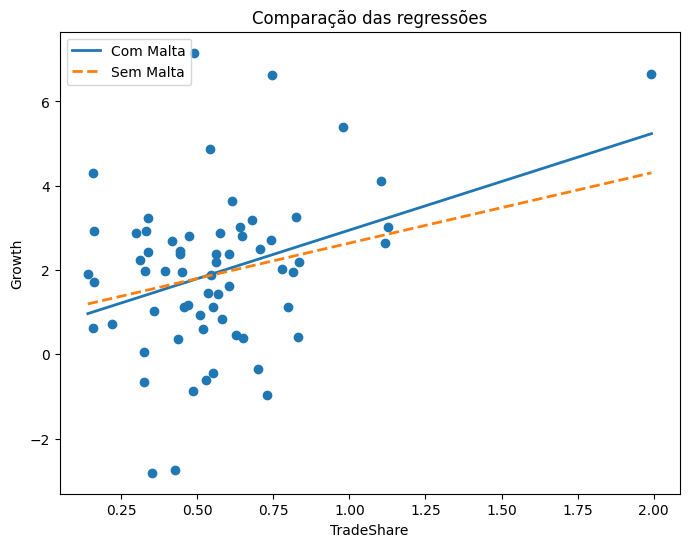


Malta é uma pequena ilha no Mar Mediterrâneo.

Ela apresenta uma participação comercial
extraordinariamente alta porque sua economia
é muito aberta ao comércio internacional.

Como Malta está muito distante dos demais países
em TradeShare, ela exerce forte influência sobre
a inclinação da reta de regressão.

Por isso costuma ser tratada como uma observação
influente (high leverage point).



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =====================================================
# Ler dados
# =====================================================

from google.colab import files

uploaded = files.upload()

df = pd.read_excel("Growth.xlsx")

print(df.head())
print(df.columns)

# =====================================================
# Questão 1
# Gráfico de dispersão
# =====================================================

plt.figure(figsize=(8,6))
plt.scatter(df["tradeshare"], df["growth"])

plt.xlabel("TradeShare")
plt.ylabel("Growth")
plt.title("Growth vs TradeShare")

plt.show()

corr = df["tradeshare"].corr(df["growth"])

print("\nCorrelação:")
print(corr)

# =====================================================
# Questão 2
# Encontrar Malta
# =====================================================

malta = df[df["country_name"] == "Malta"]

print("\nDados de Malta:")
print(malta)

plt.figure(figsize=(8,6))

plt.scatter(df["tradeshare"],
            df["growth"])

plt.scatter(malta["tradeshare"],
            malta["growth"],
            s=150)

plt.annotate(
    "Malta",
    (
        float(malta["tradeshare"]),
        float(malta["growth"])
    ),
    xytext=(10,10),
    textcoords="offset points"
)

plt.xlabel("TradeShare")
plt.ylabel("Growth")
plt.title("Malta identificada")

plt.show()

# =====================================================
# Questão 3
# Regressão com Malta
# =====================================================

X = sm.add_constant(df["tradeshare"])

modelo1 = sm.OLS(
    df["growth"],
    X
).fit()

print("\nREGRESSÃO COM MALTA")
print(modelo1.summary())

beta0_1 = modelo1.params["const"]
beta1_1 = modelo1.params["tradeshare"]

print("\nIntercepto =", beta0_1)
print("Inclinação =", beta1_1)

pred_05 = beta0_1 + beta1_1*0.5
pred_10 = beta0_1 + beta1_1*1.0

print("\nPrevisão para TradeShare = 0.5")
print(pred_05)

print("\nPrevisão para TradeShare = 1.0")
print(pred_10)

# =====================================================
# Questão 4
# Regressão sem Malta
# =====================================================

df_sem_malta = df[df["country_name"] != "Malta"]

X2 = sm.add_constant(df_sem_malta["tradeshare"])

modelo2 = sm.OLS(
    df_sem_malta["growth"],
    X2
).fit()

print("\nREGRESSÃO SEM MALTA")
print(modelo2.summary())

beta0_2 = modelo2.params["const"]
beta1_2 = modelo2.params["tradeshare"]

print("\nIntercepto =", beta0_2)
print("Inclinação =", beta1_2)

pred2_05 = beta0_2 + beta1_2*0.5
pred2_10 = beta0_2 + beta1_2*1.0

print("\nPrevisão para TradeShare = 0.5")
print(pred2_05)

print("\nPrevisão para TradeShare = 1.0")
print(pred2_10)

# =====================================================
# Questão 5
# Comparar as duas retas
# =====================================================

x = np.linspace(
    df["tradeshare"].min(),
    df["tradeshare"].max(),
    200
)

y1 = beta0_1 + beta1_1*x
y2 = beta0_2 + beta1_2*x

plt.figure(figsize=(8,6))

plt.scatter(
    df["tradeshare"],
    df["growth"]
)

plt.plot(
    x,
    y1,
    linewidth=2,
    label="Com Malta"
)

plt.plot(
    x,
    y2,
    linestyle="--",
    linewidth=2,
    label="Sem Malta"
)

plt.xlabel("TradeShare")
plt.ylabel("Growth")
plt.title("Comparação das regressões")

plt.legend()

plt.show()

# =====================================================
# Questão 6
# Informação sobre Malta
# =====================================================

print("""
Malta é uma pequena ilha no Mar Mediterrâneo.

Ela apresenta uma participação comercial
extraordinariamente alta porque sua economia
é muito aberta ao comércio internacional.

Como Malta está muito distante dos demais países
em TradeShare, ela exerce forte influência sobre
a inclinação da reta de regressão.

Por isso costuma ser tratada como uma observação
influente (high leverage point).
""")

In [3]:
# =====================================================
# Inferência para β1
# =====================================================

print(modelo2.summary())

beta1 = modelo2.params["tradeshare"]
se_beta1 = modelo2.bse["tradeshare"]
t_beta1 = modelo2.tvalues["tradeshare"]
p_beta1 = modelo2.pvalues["tradeshare"]

print("\nRESULTADOS")

print("Beta1 =", beta1)
print("Erro padrão =", se_beta1)
print("t =", t_beta1)
print("p-valor =", p_beta1)

# =========================
# IC 90%, 95% e 99%
# =========================

ic90 = modelo2.conf_int(alpha=0.10)
ic95 = modelo2.conf_int(alpha=0.05)
ic99 = modelo2.conf_int(alpha=0.01)

print("\nIC 90%")
print(ic90.loc["tradeshare"])

print("\nIC 95%")
print(ic95.loc["tradeshare"])

print("\nIC 99%")
print(ic99.loc["tradeshare"])

                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     2.898
Date:                Mon, 08 Jun 2026   Prob (F-statistic):             0.0937
Time:                        22:46:45   Log-Likelihood:                -127.04
No. Observations:                  64   AIC:                             258.1
Df Residuals:                      62   BIC:                             262.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9574      0.580      1.650      0.1

In [4]:
print(df.columns.tolist())

['country_name', 'growth', 'oil', 'rgdp60', 'tradeshare', 'yearsschool', 'rev_coups', 'assasinations']


In [5]:
# Excluir Malta

df2 = df[df["country_name"] != "Malta"].copy()

variaveis = [
    "growth",
    "tradeshare",
    "yearsschool",
    "oil",
    "rev_coups",
    "assasinations",
    "rgdp60"
]

tabela = pd.DataFrame({
    "Media": df2[variaveis].mean(),
    "Desvio_Padrao": df2[variaveis].std(),
    "Minimo": df2[variaveis].min(),
    "Maximo": df2[variaveis].max()
})

print(tabela.round(3))

                  Media  Desvio_Padrao   Minimo    Maximo
growth            1.869          1.816   -2.812     7.157
tradeshare        0.542          0.228    0.141     1.128
yearsschool       3.959          2.553    0.200    10.070
oil               0.000          0.000    0.000     0.000
rev_coups         0.170          0.225    0.000     0.970
assasinations     0.282          0.494    0.000     2.467
rgdp60         3130.813       2522.979  367.000  9895.004


In [6]:
X = df2[
    [
        "tradeshare",
        "yearsschool",
        "rev_coups",
        "assasinations",
        "rgdp60"
    ]
]

X = sm.add_constant(X)

y = df2["growth"]

modelo_multi = sm.OLS(y, X).fit()

print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     4.764
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00103
Time:                        22:46:46   Log-Likelihood:                -117.49
No. Observations:                  64   AIC:                             247.0
Df Residuals:                      58   BIC:                             259.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6269      0.783      0.801

In [7]:
media_trade = df2["tradeshare"].mean()
media_school = df2["yearsschool"].mean()
media_rev = df2["rev_coups"].mean()
media_ass = df2["assasinations"].mean()
media_rgdp = df2["rgdp60"].mean()

In [8]:
pais_medio = pd.DataFrame({
    "const":[1],
    "tradeshare":[media_trade],
    "yearsschool":[media_school],
    "rev_coups":[media_rev],
    "assasinations":[media_ass],
    "rgdp60":[media_rgdp]
})

modelo_multi.predict(pais_medio)

,0
0,1.86912


In [9]:
print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     4.764
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00103
Time:                        22:46:46   Log-Likelihood:                -117.49
No. Observations:                  64   AIC:                             247.0
Df Residuals:                      58   BIC:                             259.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6269      0.783      0.801

In [10]:
pais_medio = pd.DataFrame({
    "const":[1],
    "tradeshare":[df2["tradeshare"].mean()],
    "yearsschool":[df2["yearsschool"].mean()],
    "rev_coups":[df2["rev_coups"].mean()],
    "assasinations":[df2["assasinations"].mean()],
    "rgdp60":[df2["rgdp60"].mean()]
})

print(modelo_multi.predict(pais_medio))

0    1.86912
dtype: float64


In [11]:
pais_trade_alto = pd.DataFrame({
    "const":[1],
    "tradeshare":[
        df2["tradeshare"].mean()
        + df2["tradeshare"].std()
    ],
    "yearsschool":[df2["yearsschool"].mean()],
    "rev_coups":[df2["rev_coups"].mean()],
    "assasinations":[df2["assasinations"].mean()],
    "rgdp60":[df2["rgdp60"].mean()]
})

print(modelo_multi.predict(pais_trade_alto))

0    2.175273
dtype: float64


1. Gráfico mostrando o efeito de incluir Oil

In [12]:
import statsmodels.api as sm

X_oil = df2[
    [
        "tradeshare",
        "yearsschool",
        "rev_coups",
        "assasinations",
        "rgdp60",
        "oil"
    ]
]

X_oil = sm.add_constant(X_oil)

modelo_oil = sm.OLS(
    df2["growth"],
    X_oil
).fit()

print(modelo_oil.summary())

                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     4.764
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00103
Time:                        22:46:46   Log-Likelihood:                -117.49
No. Observations:                  64   AIC:                             247.0
Df Residuals:                      58   BIC:                             259.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6269      0.783      0.801

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


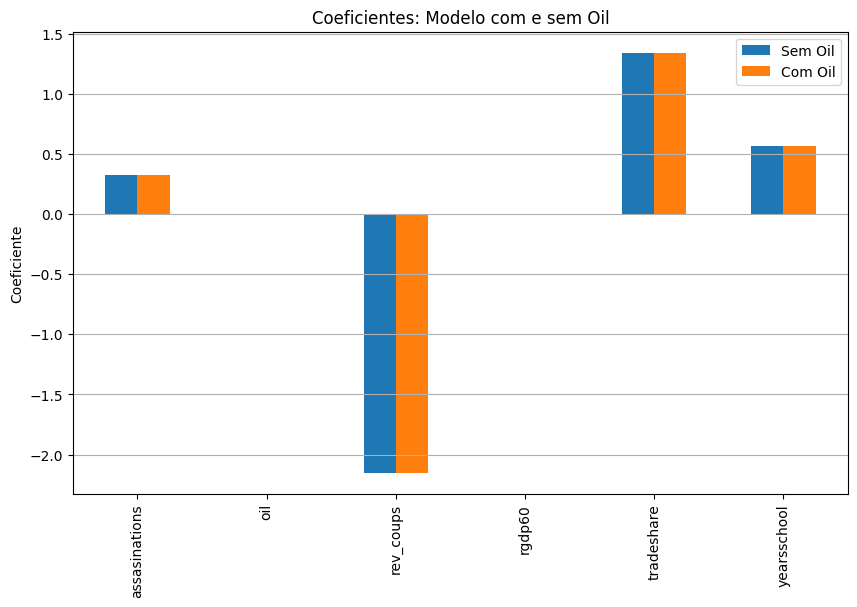

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

comparacao = pd.DataFrame({
    "Sem Oil": modelo_multi.params,
    "Com Oil": modelo_oil.params
})

comparacao = comparacao.drop("const")

comparacao.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Coeficientes: Modelo com e sem Oil")
plt.ylabel("Coeficiente")
plt.grid(axis="y")
plt.show()

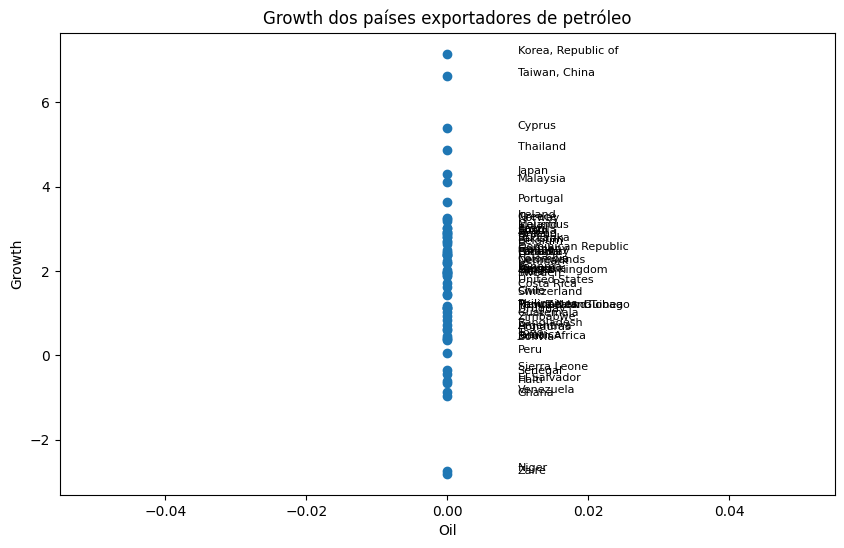

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(
    df2["oil"],
    df2["growth"]
)

for i,row in df2.iterrows():
    plt.text(
        row["oil"]+0.01,
        row["growth"],
        row["country_name"],
        fontsize=8
    )

plt.xlabel("Oil")
plt.ylabel("Growth")
plt.title("Growth dos países exportadores de petróleo")

plt.show()

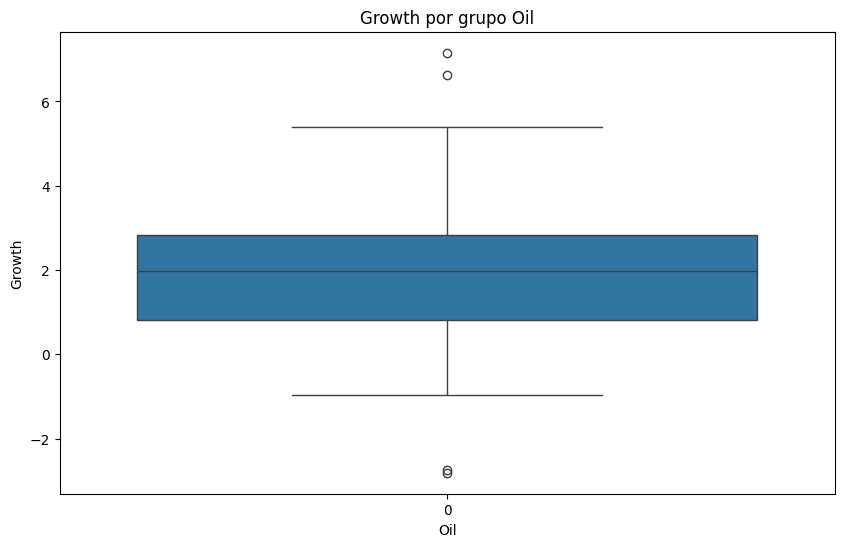

In [15]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    x="oil",
    y="growth",
    data=df2
)

plt.title("Growth por grupo Oil")
plt.xlabel("Oil")
plt.ylabel("Growth")

plt.show()

2. Países mais afetados por revoluções e golpes (Rev_Coups)

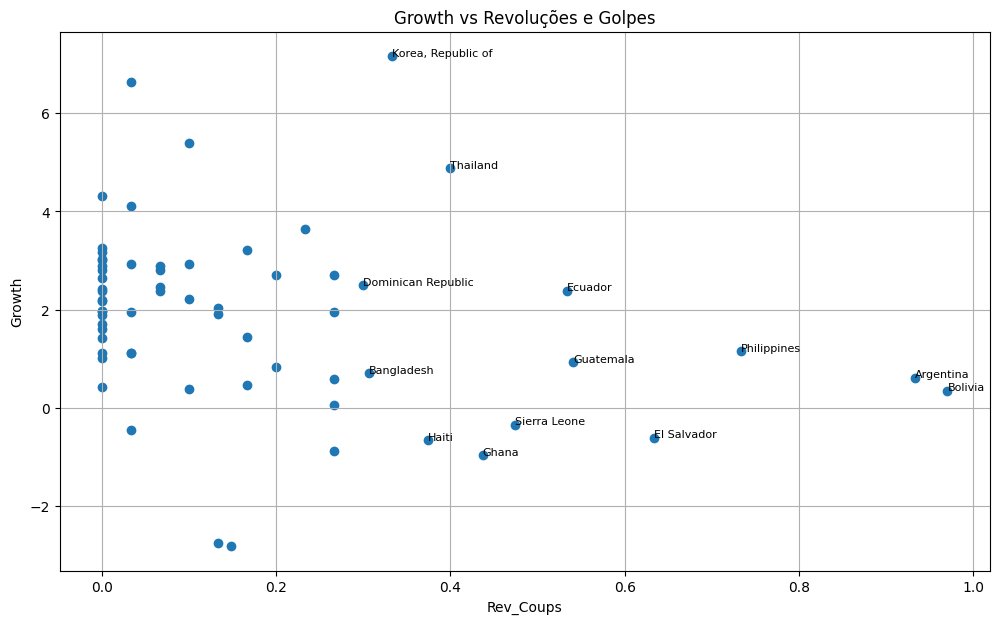

In [16]:
plt.figure(figsize=(12,7))

plt.scatter(
    df2["rev_coups"],
    df2["growth"]
)

for i,row in df2.iterrows():

    if row["rev_coups"] > 0.30:

        plt.text(
            row["rev_coups"],
            row["growth"],
            row["country_name"],
            fontsize=8
        )

plt.xlabel("Rev_Coups")
plt.ylabel("Growth")
plt.title("Growth vs Revoluções e Golpes")

plt.grid(True)

plt.show()

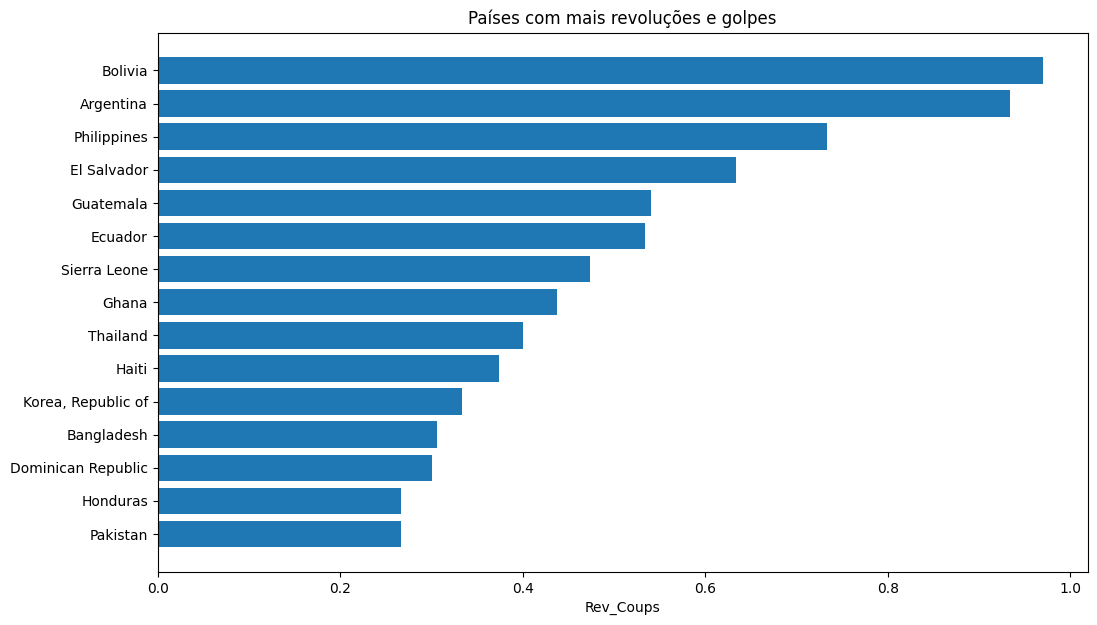

In [17]:
top = df2.sort_values(
    "rev_coups",
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top["country_name"],
    top["rev_coups"]
)

plt.xlabel("Rev_Coups")
plt.title("Países com mais revoluções e golpes")

plt.gca().invert_yaxis()

plt.show()

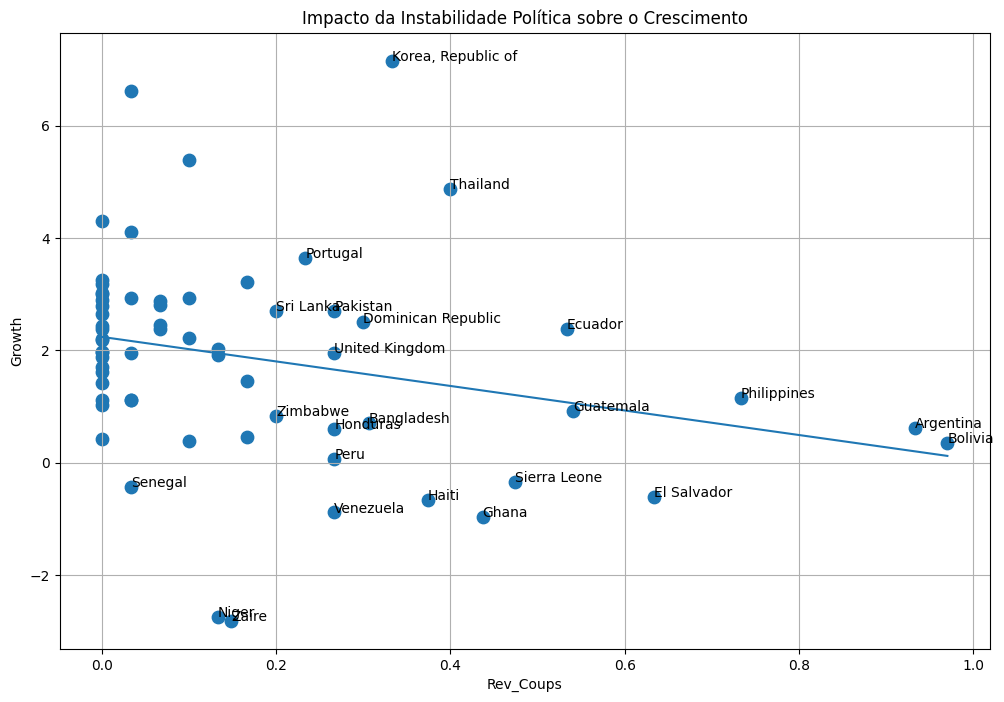

In [18]:
plt.figure(figsize=(12,8))

plt.scatter(
    df2["rev_coups"],
    df2["growth"],
    s=80
)

for _, row in df2.iterrows():

    if (
        row["rev_coups"] > 0.20
        or
        row["growth"] < 0
    ):

        plt.annotate(
            row["country_name"],
            (
                row["rev_coups"],
                row["growth"]
            )
        )

plt.xlabel("Rev_Coups")
plt.ylabel("Growth")
plt.title("Impacto da Instabilidade Política sobre o Crescimento")

coef = np.polyfit(
    df2["rev_coups"],
    df2["growth"],
    1
)

x = np.linspace(
    df2["rev_coups"].min(),
    df2["rev_coups"].max(),
    100
)

plt.plot(
    x,
    coef[0]*x + coef[1]
)

plt.grid(True)

plt.show()

In [19]:
impactados = df2.sort_values(
    ["rev_coups","growth"],
    ascending=[False,True]
)

print(
    impactados[
        ["country_name",
         "rev_coups",
         "growth"]
    ].head(15)
)

          country_name  rev_coups    growth
19             Bolivia   0.970370  0.355058
1            Argentina   0.933333  0.617645
24         Philippines   0.733333  1.158741
30         El Salvador   0.633333 -0.607556
28           Guatemala   0.540741  0.929231
36             Ecuador   0.533333  2.388093
49        Sierra Leone   0.474074 -0.339834
51               Ghana   0.437037 -0.963162
32            Thailand   0.400000  4.876695
9                Haiti   0.374074 -0.657934
27  Korea, Republic of   0.333333  7.156855
5           Bangladesh   0.306481  0.708263
50  Dominican Republic   0.300000  2.498769
26           Venezuela   0.266667 -0.883551
8                 Peru   0.266667  0.060206


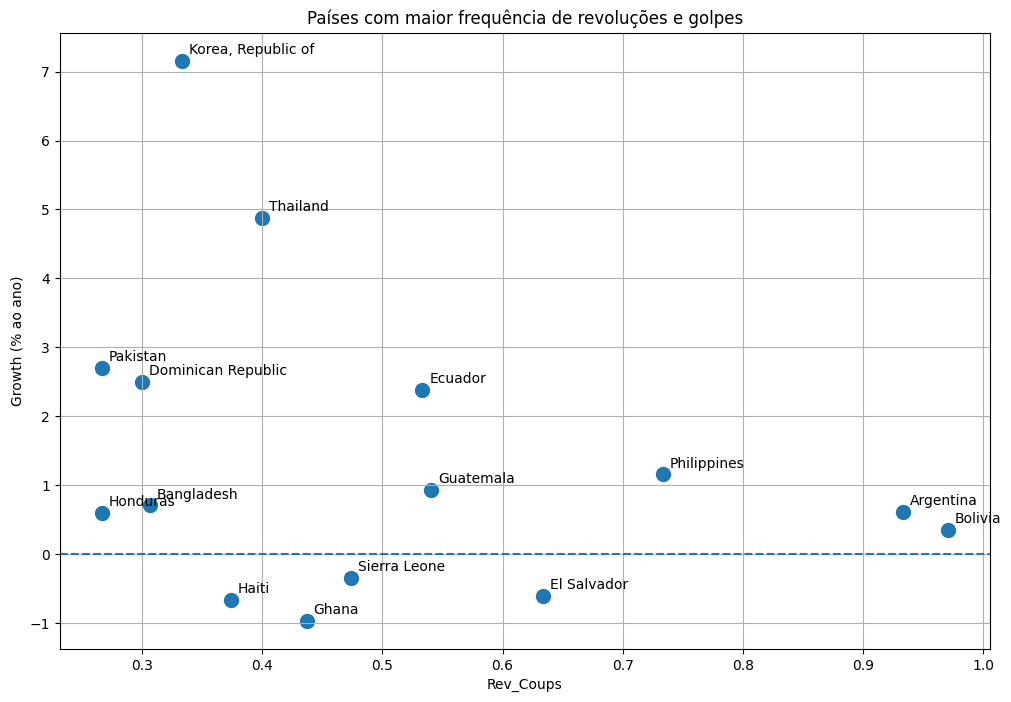

In [20]:
import matplotlib.pyplot as plt

top = df2.sort_values(
    "rev_coups",
    ascending=False
).head(15)

plt.figure(figsize=(12,8))

plt.scatter(
    top["rev_coups"],
    top["growth"],
    s=100
)

for _, row in top.iterrows():

    plt.annotate(
        row["country_name"],
        (
            row["rev_coups"],
            row["growth"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Rev_Coups")
plt.ylabel("Growth (% ao ano)")
plt.title(
    "Países com maior frequência de revoluções e golpes"
)

plt.grid(True)

plt.show()

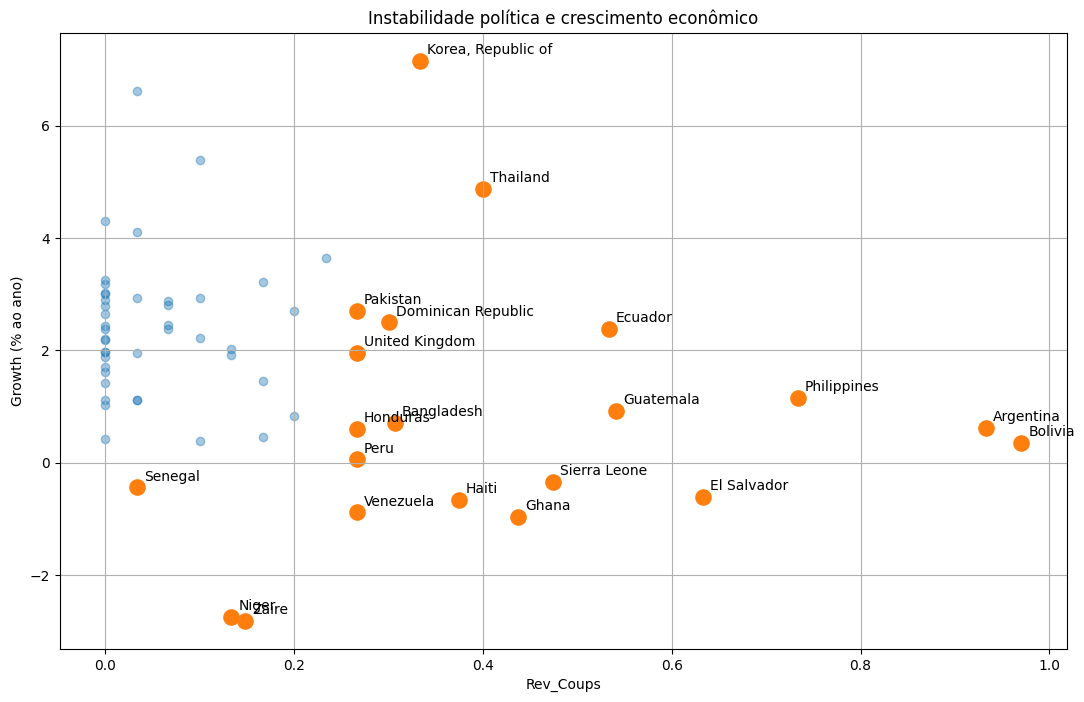

In [21]:
extremos = df2[
    (df2["rev_coups"] > 0.25)
    |
    (df2["growth"] < 0)
]

plt.figure(figsize=(13,8))

plt.scatter(
    df2["rev_coups"],
    df2["growth"],
    alpha=0.4
)

plt.scatter(
    extremos["rev_coups"],
    extremos["growth"],
    s=120
)

for _, row in extremos.iterrows():

    plt.annotate(
        row["country_name"],
        (
            row["rev_coups"],
            row["growth"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Rev_Coups")
plt.ylabel("Growth (% ao ano)")
plt.title(
    "Instabilidade política e crescimento econômico"
)

plt.grid(True)

plt.show()

Embora o coeficiente estimado de Rev_Coups seja negativo (-2,1504), os dados revelam considerável heterogeneidade entre os países. Alguns países com elevada frequência de golpes e revoluções, como Coreia do Sul e Tailândia, apresentaram altas taxas de crescimento econômico. Isso sugere que outros fatores estruturais, como capital humano, industrialização e abertura econômica, também desempenham papel importante na determinação do crescimento, reduzindo a força da relação observada entre instabilidade política e crescimento econômico.